In [35]:
from pandas import DataFrame
import yfinance as yf
import pandas as pd

def get_stock_data(ticker="AAPL", start="2020-01-01", end="2024-01-01"):
    df = yf.download(ticker, start=start, end=end)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)

    return df


def normalize_df_zscore(data):
    data = data.copy()
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        mean = data[col].mean()
        std = data[col].std()
        data[col] = (data[col] - mean)/(std + 1e-8)
    data.dropna(inplace=True)
    return data


In [37]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces
import matplotlib.pyplot as plt


class StockTradingEnv(gym.Env):
    def __init__(self, df):
        super(StockTradingEnv, self).__init__()
        self.original_df = df
        self.df = normalize_df_zscore(df)
        self.n_steps = len(self.df)
        self.current_step = 0

        #ACTIONS
        self.action_space = spaces.Discrete(3)  # 0: hold, 1: buy, 2: sell

        #OBSERVATION SPACE
        self.window_size = 14
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window_size, self.df.shape[1]), dtype=np.float32)

        #SET VARIABLES TO CONTROL REWARDS
        self.initial_balance = 10000
        self.balance = self.initial_balance
        self.shares_held = 0
        self.net_worth = self.initial_balance
        self.max_net_worth = self.initial_balance
        self.last_net_worth = self.initial_balance
        self.number_days_hold = 1



    def _next_observation(self):
        start = self.current_step - self.window_size + 1
        end = self.current_step + 1

        # Handle beginning of episode
        if start < 0:
            pad = np.zeros((abs(start), self.df.shape[1]))
            obs = np.vstack((pad, self.df.iloc[0:end].values))
        else:
            obs = self.df.iloc[start:end].values

        return obs.astype(np.float32)


    def step(self, action):
        current_price = float(self.original_df.iloc[self.current_step]["Close"])
        executed_action = 0
        if action == 1 :  # Buy
            if self.balance > 0:
                self.shares_held = self.balance / current_price
                self.balance = 0
                executed_action = 1
        elif action == 2:  # Sell
            if self.shares_held > 0:
                self.balance = self.shares_held * current_price
                self.shares_held = 0
                executed_action = 2
                self.number_days_hold = 1

        self.net_worth = self.balance + self.shares_held * current_price
        if self.shares_held > 0:
            self.number_days_hold =min(max(self.number_days_hold*(self.number_days_hold +1), 1), 100_000_000)

        reward = (self.net_worth - self.last_net_worth)*10/self.number_days_hold
        self.last_net_worth = self.net_worth
        self.net_worths.append(self.net_worth)
        self.actions.append(executed_action)

        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1
        truncated = False  # Or set appropriate truncation logic

        return self._next_observation(), reward, terminated, truncated, {
            "net_worth": self.net_worth,
            "shares_held": self.shares_held,
            "balance": self.balance,
            "actions": self.actions,
        }



    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size - 1
        self.balance = self.initial_balance
        self.shares_held = 0
        self.net_worth = self.initial_balance
        self.max_net_worth = self.initial_balance
        self.last_net_worth = self.initial_balance
        self.net_worths = []
        self.actions = []
        return self._next_observation(), {}


    def render(self, mode='human'):
        if not hasattr(self, "net_worths") or len(self.net_worths) == 0:
            print("No data to render yet.")
            return

        prices = self.original_df['Close'].iloc[self.window_size:self.window_size+len(self.net_worths)].reset_index(drop=True)
        plt.figure(figsize=(12, 6))

        # Plot net worth
        plt.plot(self.net_worths, label='Net Worth', color='blue')

        # Optional: show buy/sell points
        for i, action in enumerate(self.actions):
            if action == 1:  # Buy
                plt.scatter(i, self.net_worths[i], marker='^', color='green')
            elif action == 2:  # Sell
                plt.scatter(i, self.net_worths[i], marker='v', color='red')
            elif action == 0:
                plt.scatter(i, self.net_worths[i], marker='o', color='black')

        plt.title("Net Worth Over Time")
        plt.xlabel("Time Step")
        plt.ylabel("Net Worth")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

[*********************100%***********************]  1 of 1 completed
/var/folders/rf/wm_j98lj3pz_hzy5g_tc1mmr0000gn/T/ipykernel_64658/1503461143.py:48: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(self.original_df.iloc[self.current_step]["Close"])


Price            Open       High        Low      Close     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  71.627092  72.681289  71.373218  72.620842  135480400
2020-01-03  71.847125  72.676454  71.689965  71.914825  146322800
2020-01-06  71.034694  72.526518  70.783234  72.487831  118387200
2020-01-07  72.497514  72.753808  71.926900  72.146927  108872000
2020-01-08  71.849548  73.609760  71.849548  73.307526  132079200
Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2744 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2130         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 40

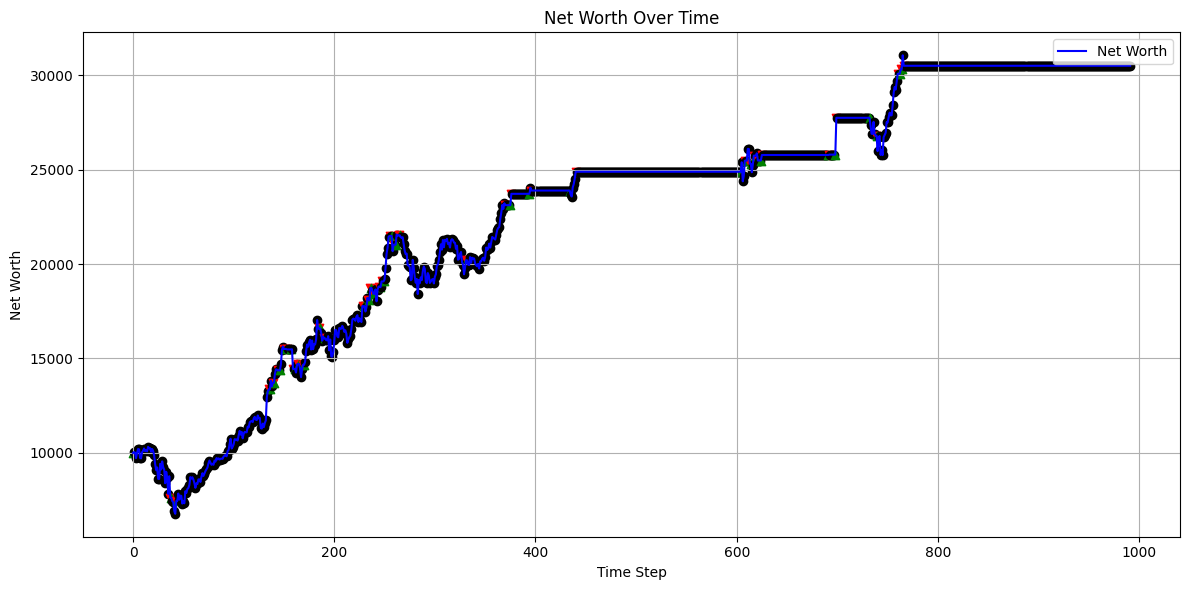

In [43]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

df = get_stock_data("AAPL", start="2020-01-01", end="2024-01-01")
print(df.head())
env = DummyVecEnv([lambda: StockTradingEnv(df)])

model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=500000)
model.save("models/ppo_stock_trader_3")

env = StockTradingEnv(df)
obs, _ = env.reset()

for _ in range(len(df) - env.window_size):
    action, _ = model.predict(obs, deterministic=True)
    obs, _, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
        break

env.render()



[*********************100%***********************]  1 of 1 completed
/var/folders/rf/wm_j98lj3pz_hzy5g_tc1mmr0000gn/T/ipykernel_64658/1503461143.py:48: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(self.original_df.iloc[self.current_step]["Close"])


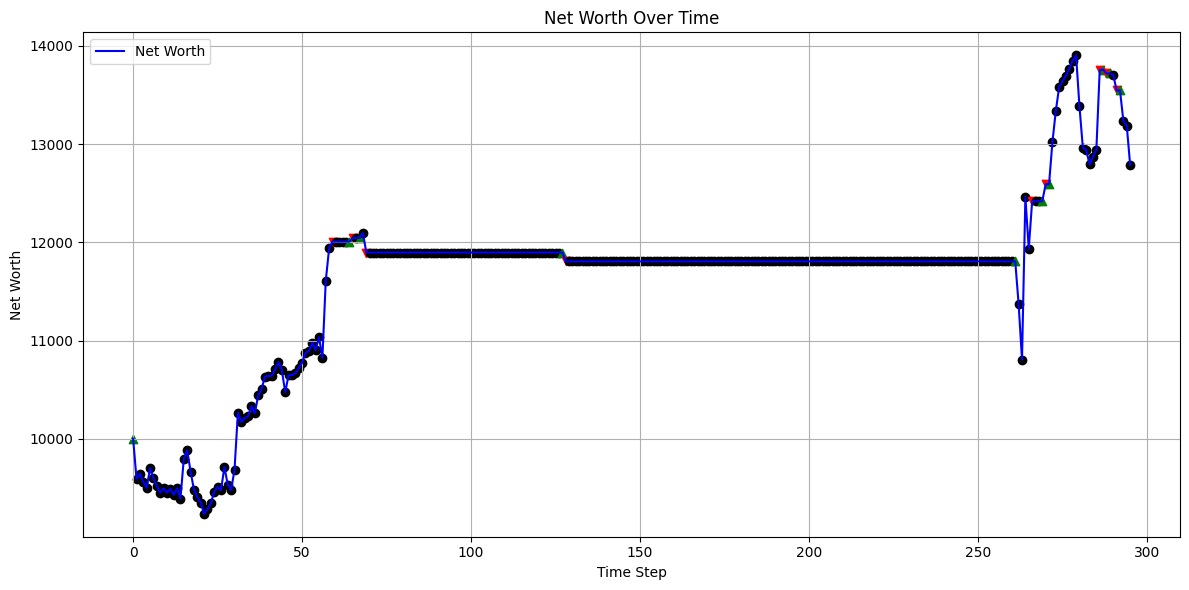

In [44]:
## Take the last 50 rows

partial_df = get_stock_data(ticker="AAPL", start="2024-03-01", end="2025-05-28")


env = StockTradingEnv(partial_df)
obs , _ = env.reset()

terminated = False
truncated = False

while not truncated and not terminated :
    action, _ = model.predict(obs, deterministic=True)
    obs, _, terminated, truncated, results = env.step(action)


env.render()

In [76]:
import numpy as np

actions = results['actions']  # assuming this is a list or 1D array of integers 0, 1, 2
actions_array = np.array(actions)
counts = np.bincount(actions_array, minlength=3)  # Creates counts for 0, 1, 2

num_zeros = counts[0]
num_ones = counts[1]
num_twos = counts[2]

print(f"Number of action 0 (hold): {num_zeros}")
print(f"Number of action 1 (buy): {num_ones}")
print(f"Number of action 2 (sell): {num_twos}")


Number of action 0 (hold): 62
Number of action 1 (buy): 6
Number of action 2 (sell): 6
